In [15]:
import setup
from importlib import reload
reload(setup)
from setup import *
Ru_comp = 0.33

# 1D Fickian diffusion 
henry_constant = 1e-3 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL_micron = 1e-6 # Setting the denominator to 1 micron to allow for delta_BL to be in microns
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL_micron
log_k1_fick = np.log(k1_fick)

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.38,15
,3000,0,0.44,7
,3000,0,0.45,15
,3000,0,0.38,15


Computed from 4000 posterior samples and 748 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   141.79    36.92
p_loo       11.08        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      748  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



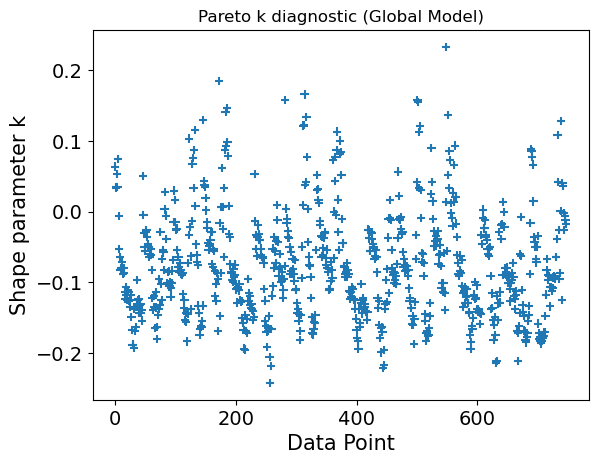

In [10]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.073  0.004  -0.081   -0.066      0.000      0.0    1568.0    2182.0    1.0
deltaG4_0   0.899  0.007   0.885    0.911      0.000      0.0    1444.0    1836.0    1.0
Gact2_0     0.686  0.002   0.682    0.689      0.000      0.0    1730.0    2288.0    1.0
sigma_rel   0.372  0.026   0.327    0.423      0.001      0.0    1818.0    2166.0    1.0
sigma_base  0.005  0.004   0.000    0.012      0.000      0.0    2305.0    1665.0    1.0
exponent    0.375  0.021   0.335    0.413      0.001      0.0    1537.0    2178.0    1.0


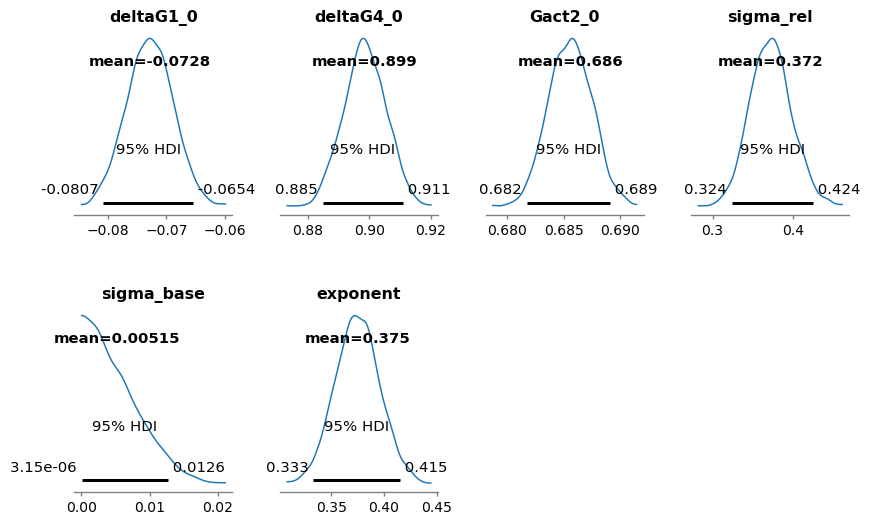

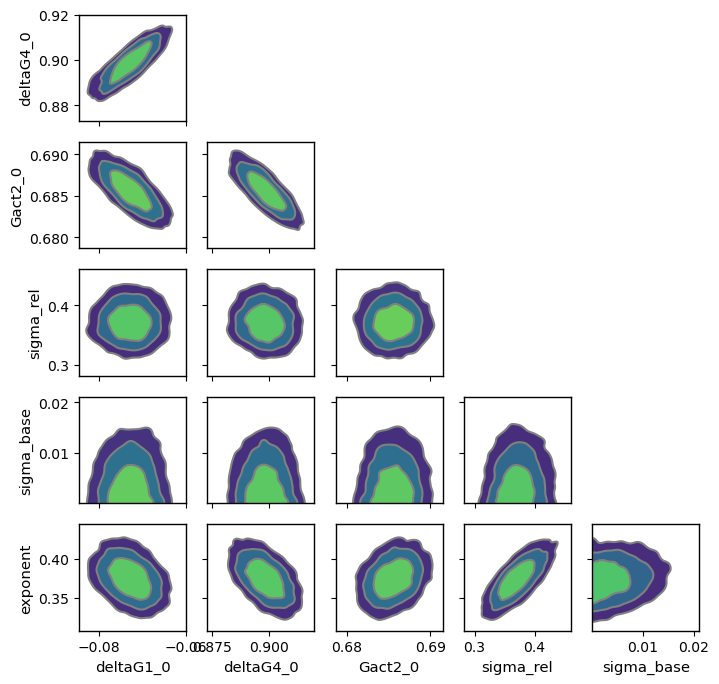

Sampling: [rate]


rate: 0.493


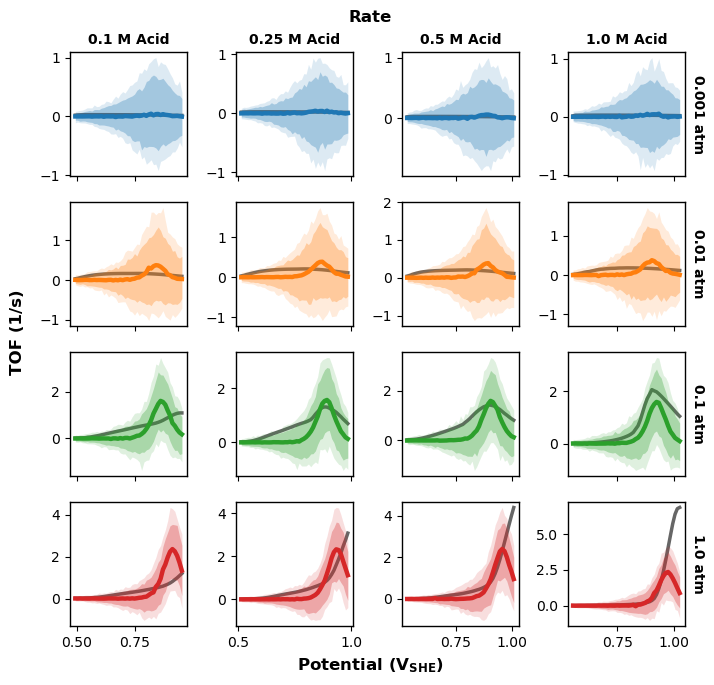

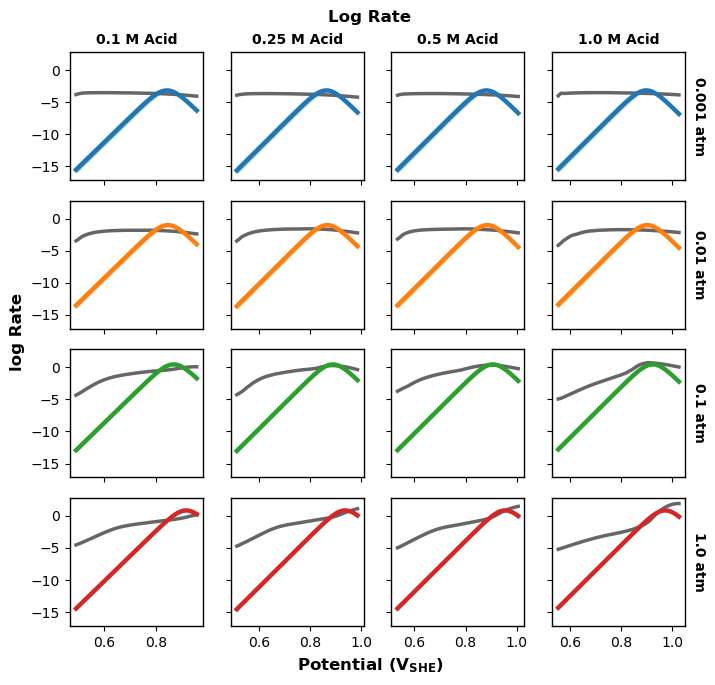

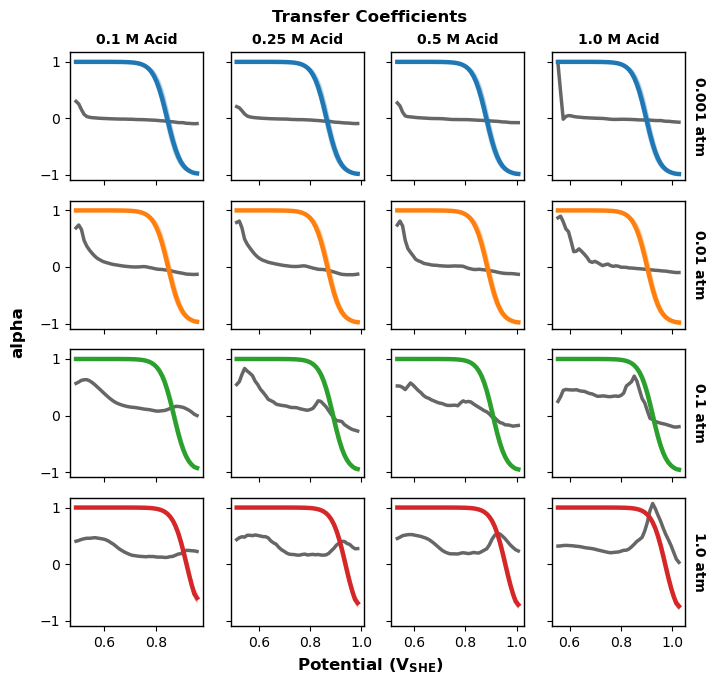

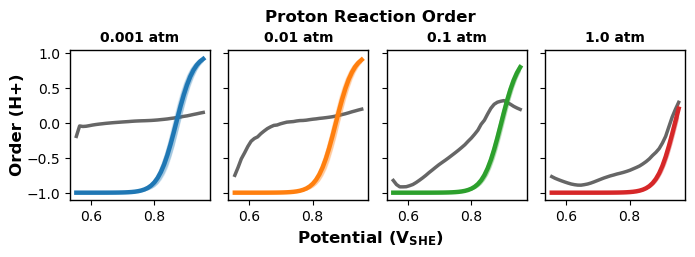

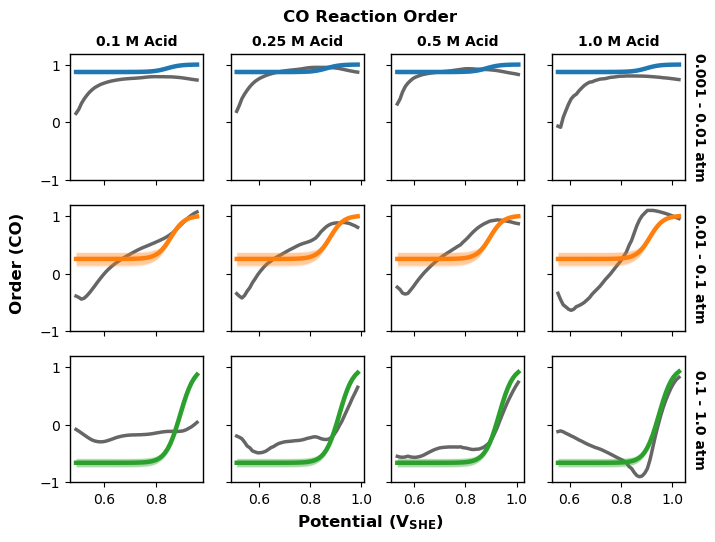

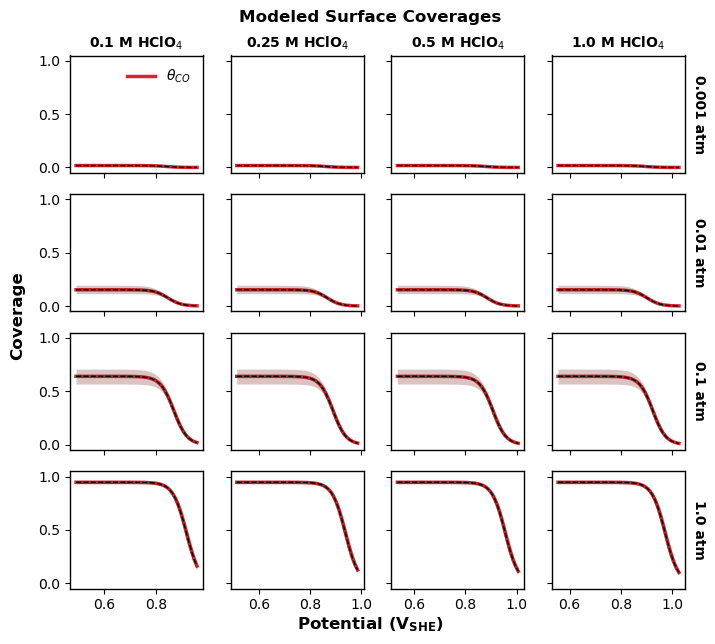

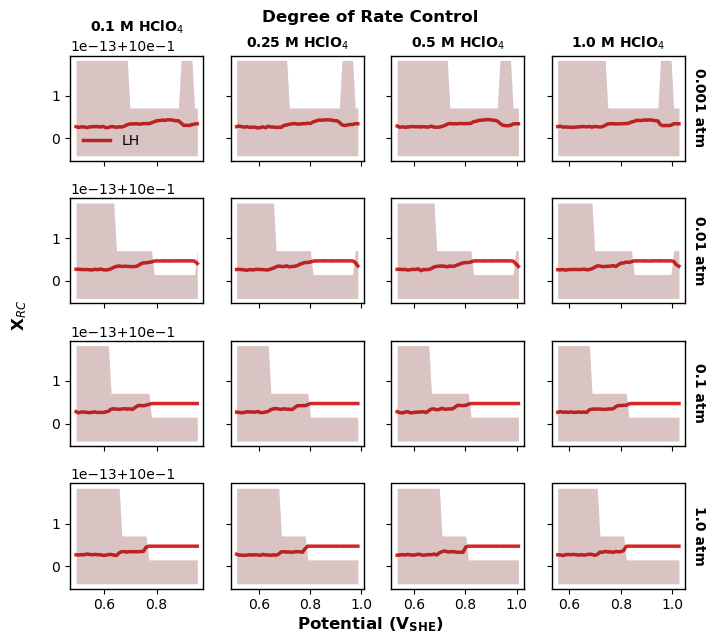

In [11]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)
plot_drc(LH_2, trace_LH_2, perturb_vars=['Gact2_0'], perturb_labels=['LH'])

# BF 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,21,0.25,63
,3000,279,0.03,7
,3000,0,0.18,31
,3000,0,0.04,15


Computed from 4000 posterior samples and 748 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   743.45    66.31
p_loo        8.96        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      748  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



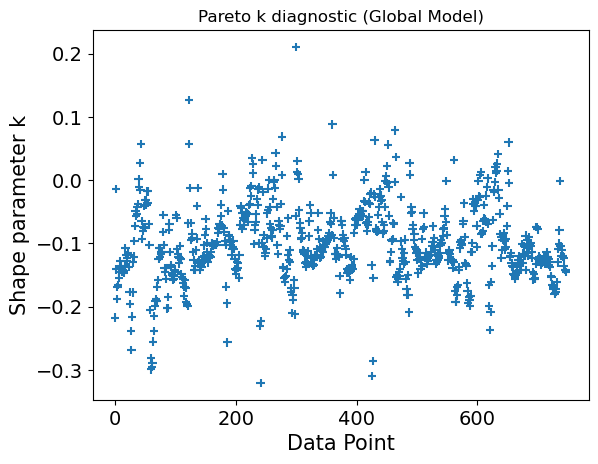

In [12]:
with pm.Model() as BF_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    5. H2O + # <-> OH# + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pt = log_K4 - np.log(C_H_in)
    term_OH_Ru = log_K5 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pt = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pt]), axis=0)
    log_theta_Ru = - pt.logsumexp(pt.stack([zeros, term_OH_Ru]), axis=0)
    log_theta_CO = term_CO + log_theta_Pt
    log_theta_OH_Pt = term_OH_Pt + log_theta_Pt
    log_theta_OH_Ru = term_OH_Ru + log_theta_Ru

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pt = pm.Deterministic('theta_OH_Pt', pt.exp(log_theta_OH_Pt))
    theta_OH_Ru = pm.Deterministic('theta_OH_Ru', pt.exp(log_theta_OH_Ru))
    theta_empty_Pt = pm.Deterministic('theta_empty_Pt', pt.exp(log_theta_Pt))
    theta_empty_Ru = pm.Deterministic('theta_empty_Ru', pt.exp(log_theta_Ru))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ru + np.log(Ru_comp)
    rate = observables(log_rate) 

trace_BF_2, loo_BF_2 = fit_and_evaluate(BF_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.104  0.001  -0.106   -0.102      0.000    0.000     345.0     924.0   1.08
deltaG4_0   1.015  0.003   1.008    1.021      0.001    0.000      16.0     145.0   1.18
deltaG5_0  -0.079  0.225  -0.366    0.366      0.069    0.005      12.0     625.0   1.26
Gact2_0     0.741  0.002   0.738    0.745      0.001    0.000      10.0      98.0   1.32
beta_2      0.007  0.003   0.003    0.012      0.001    0.000       7.0      12.0   1.56
sigma_rel   2.254  0.223   1.817    2.621      0.050    0.004      21.0    1023.0   1.13
sigma_base  0.002  0.000   0.002    0.003      0.000    0.000      21.0      68.0   1.13
exponent    4.619  0.155   4.308    4.895      0.022    0.012      46.0    1060.0   1.10


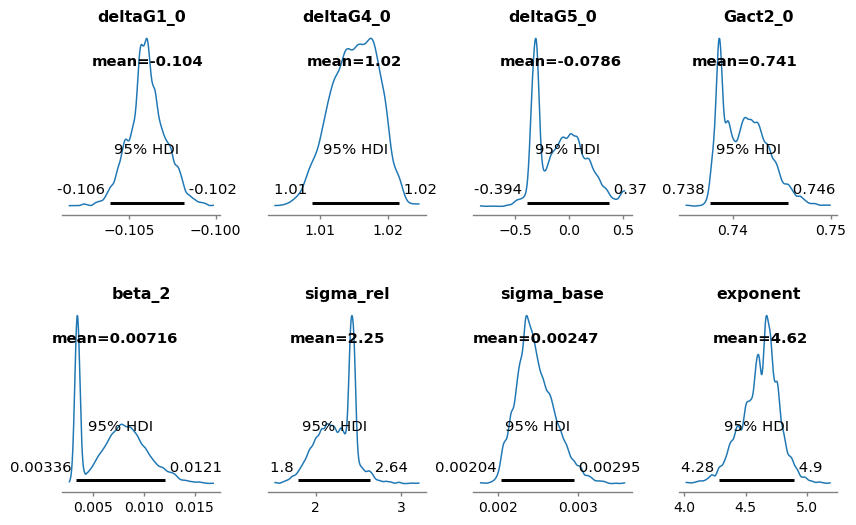

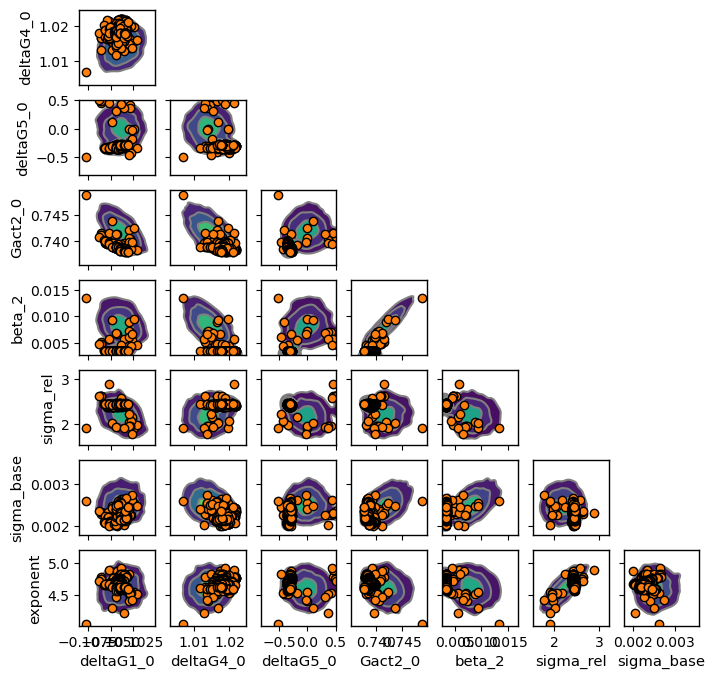

Sampling: [rate]


rate: 0.311


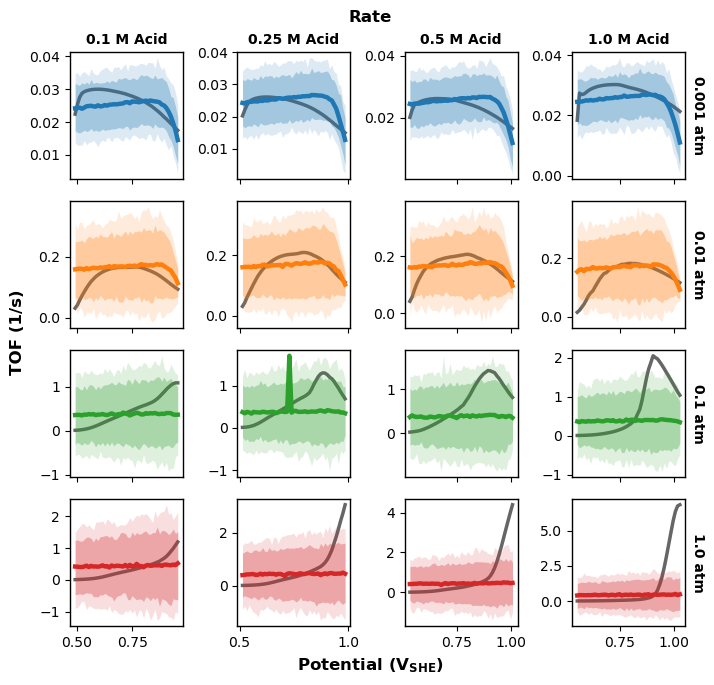

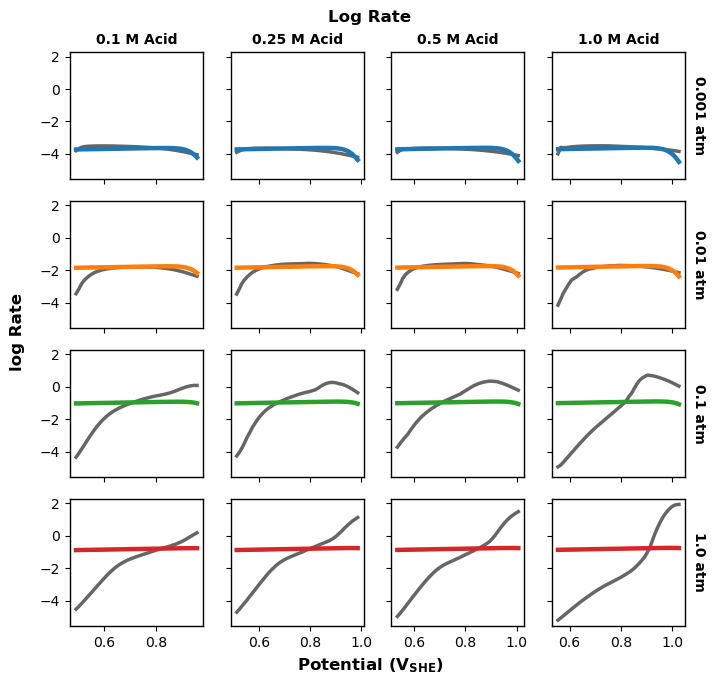

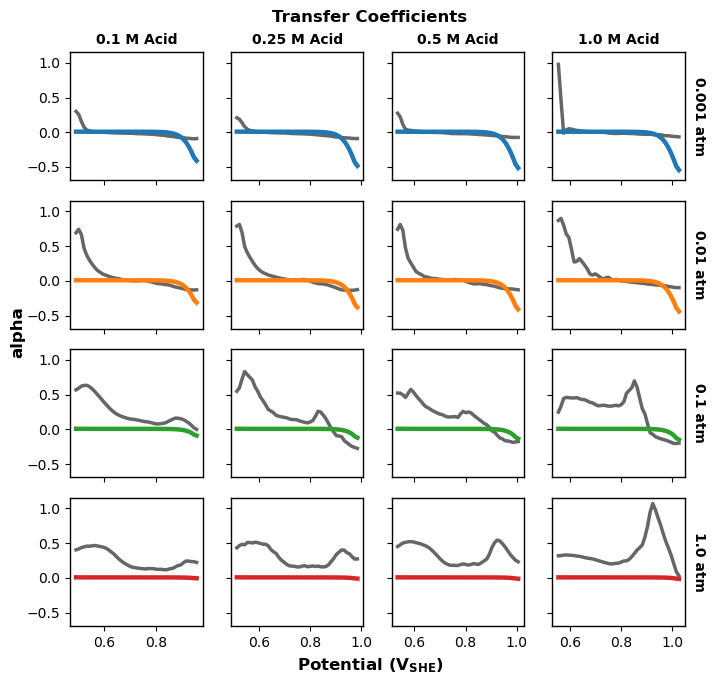

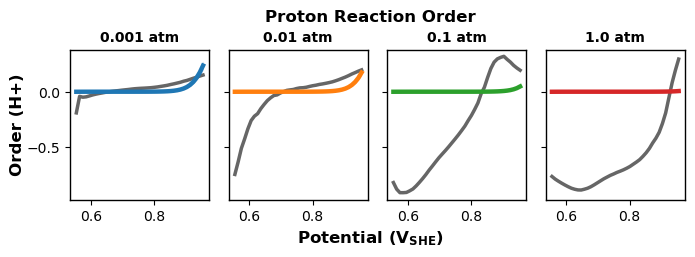

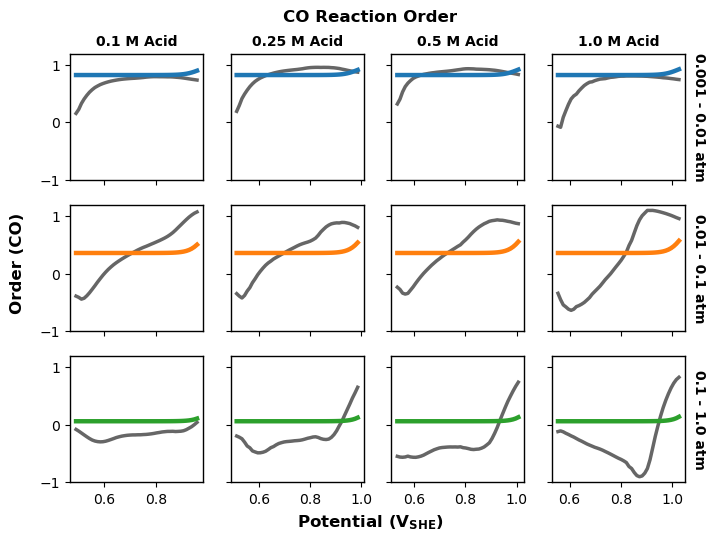

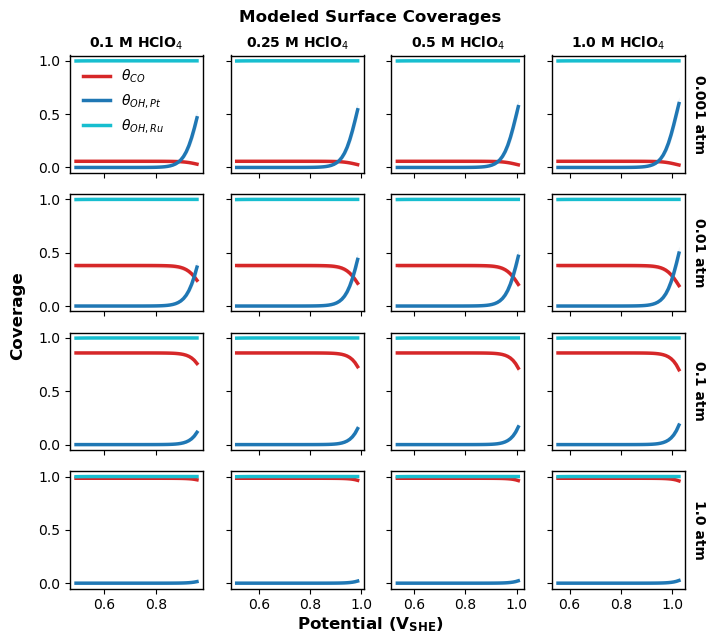

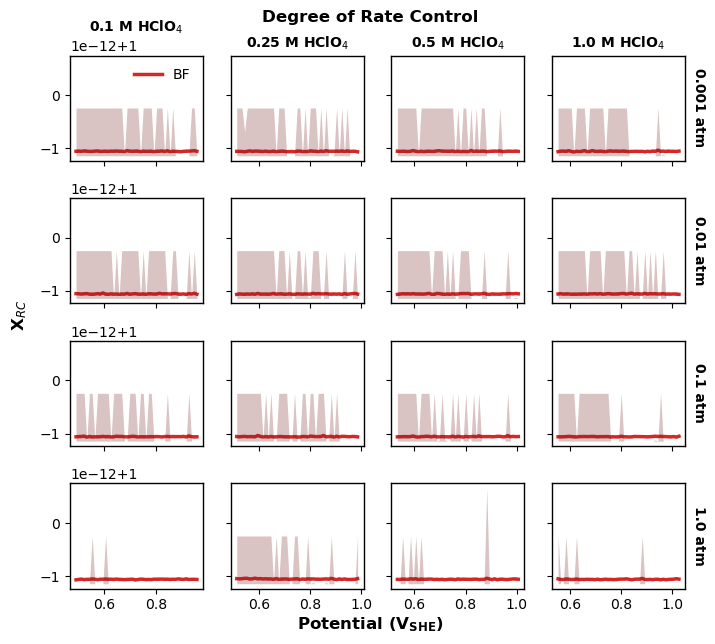

In [13]:
ppc_BF_2 = plot_posteriors(trace_BF_2, BF_2)
plot_model_fits(trace_BF_2, ppc_BF_2); plot_coverages(trace_BF_2)
plot_drc(BF_2, trace_BF_2, perturb_vars=['Gact2_0'], perturb_labels=['BF'])

# LH 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,107,0.28,15
,3000,87,0.28,15
,3000,96,0.41,15
,3000,107,0.39,7


Computed from 4000 posterior samples and 748 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -399.20    51.05
p_loo        1.89        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      748  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



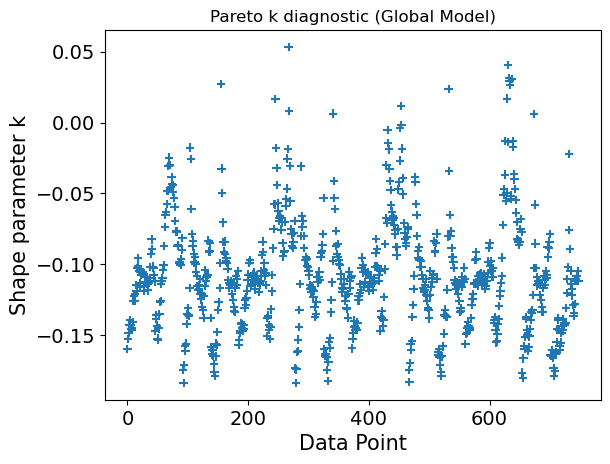

In [16]:
with pm.Model() as LH_1_2:
    '''
    1. CO + * <-> CO* (Fick) (Irr) (SSA)
    2. CO* + OH* -> COOH* + * (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_OH = log_K4 - np.log(C_H_in)
    log_theta_CO = log_k1 + np.log(P_CO_in) - (log_k2 + term_OH)

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_empty = pm.Deterministic('theta_empty', (1.0 - theta_CO) / (1.0 + pt.exp(term_OH)))
    theta_OH = pm.Deterministic('theta_OH', theta_empty * pt.exp(term_OH))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + pt.log(theta_OH)
    rate = observables(log_rate) 

trace_LH_1_2, loo_LH_1_2 = fit_and_evaluate(LH_1_2)

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   -0.019  0.187  -0.342    0.353      0.003    0.003    3015.0    2354.0    1.0
Gact2_0      0.688  0.192   0.318    1.043      0.003    0.003    3302.0    2634.0    1.0
delta_BL    10.363  4.704   2.423   19.727      0.124    0.086    1232.0     855.0    1.0
sigma_rel    0.185  0.011   0.166    0.204      0.000    0.000    2476.0    1634.0    1.0
sigma_base   0.008  0.006   0.000    0.019      0.000    0.000    2058.0    1434.0    1.0
exponent     0.002  0.002   0.000    0.005      0.000    0.000    1629.0    1526.0    1.0


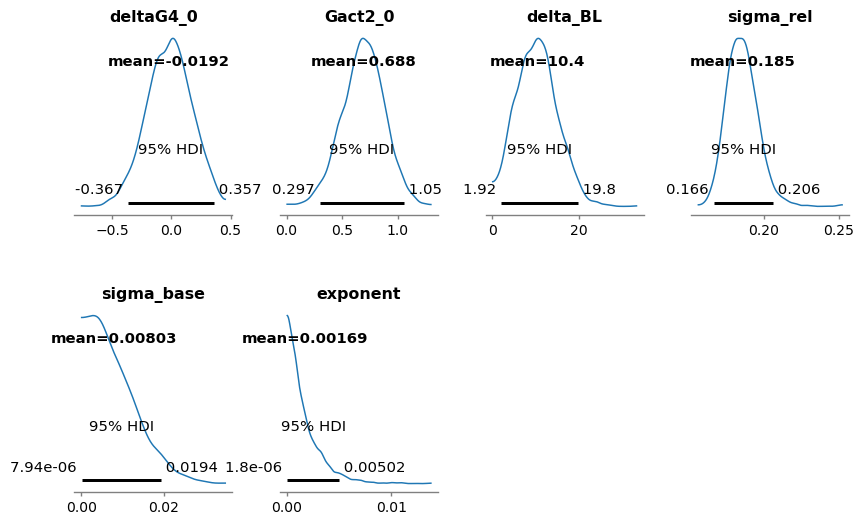

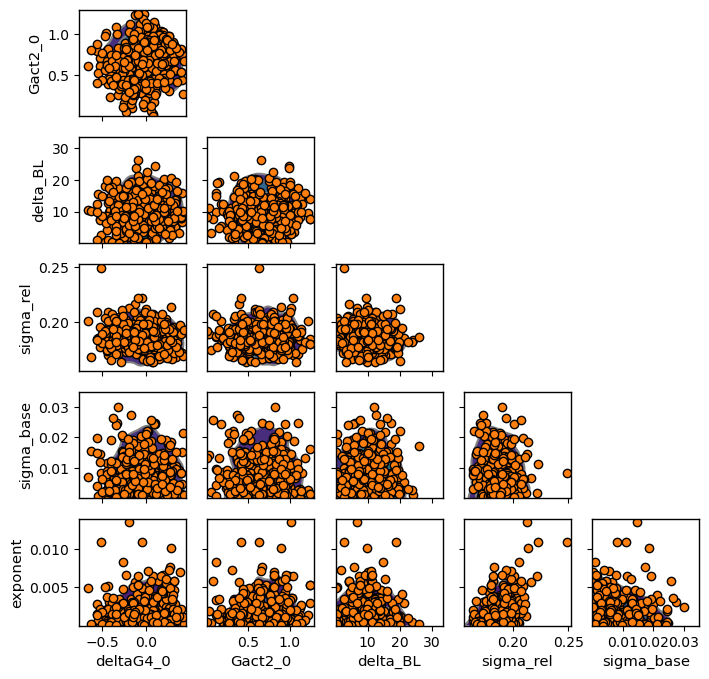

Sampling: [rate]


rate: 0.249


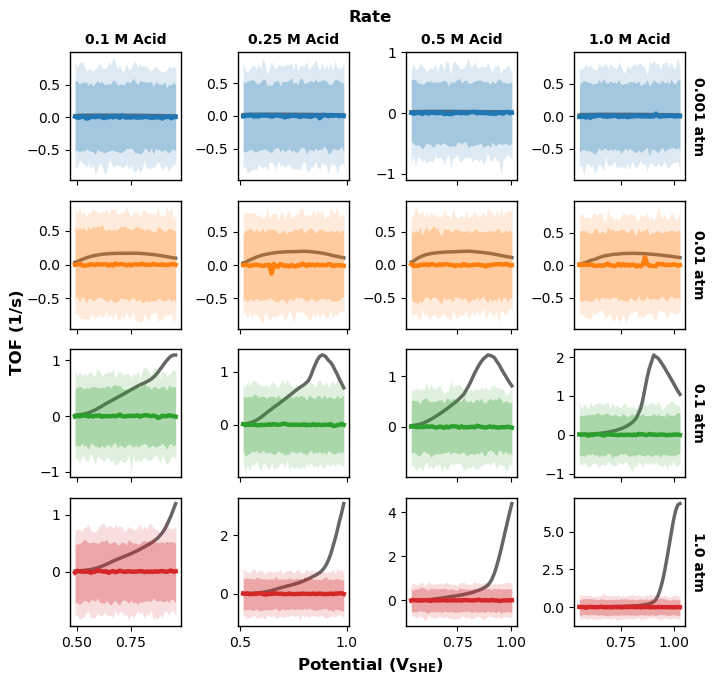

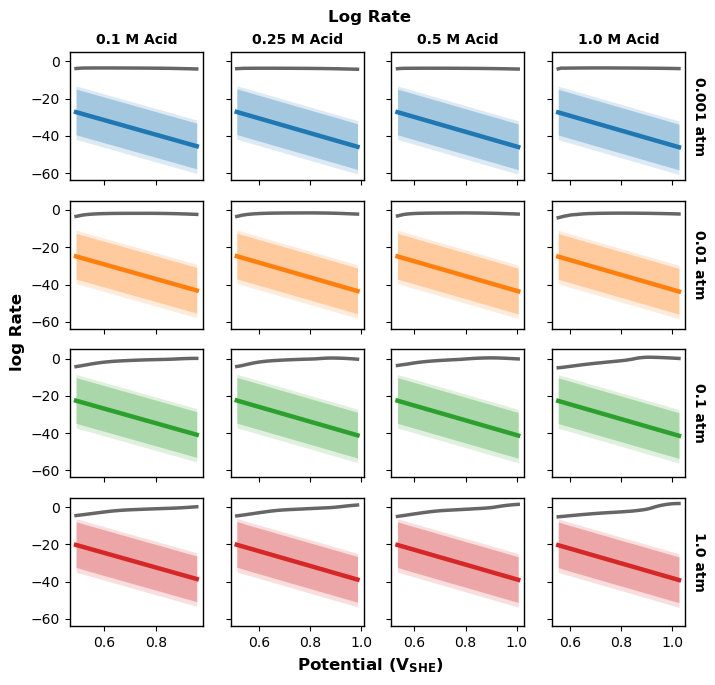

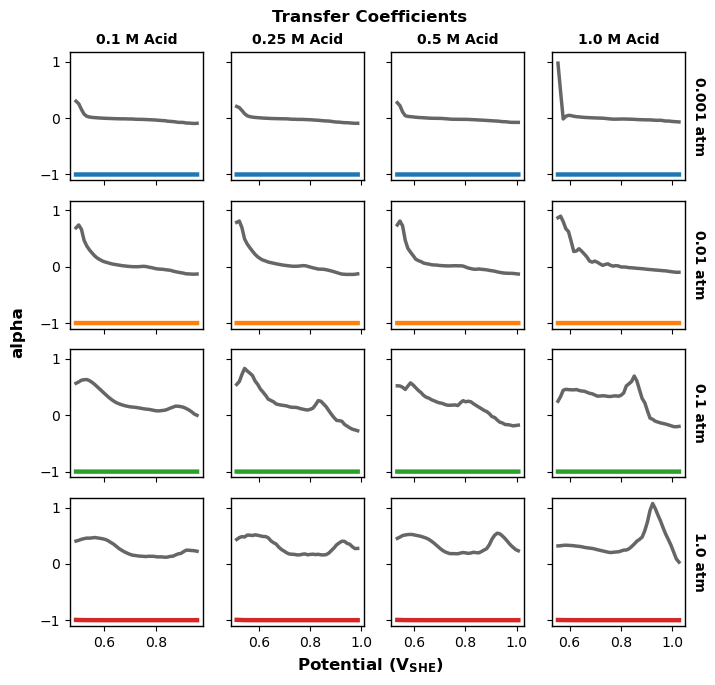

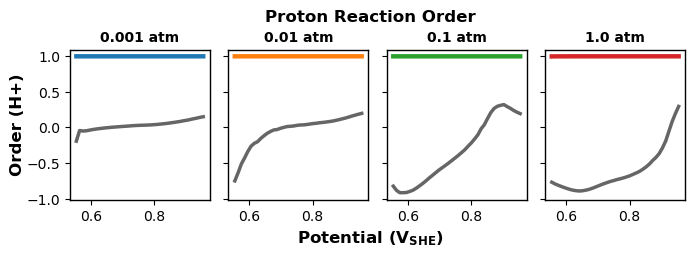

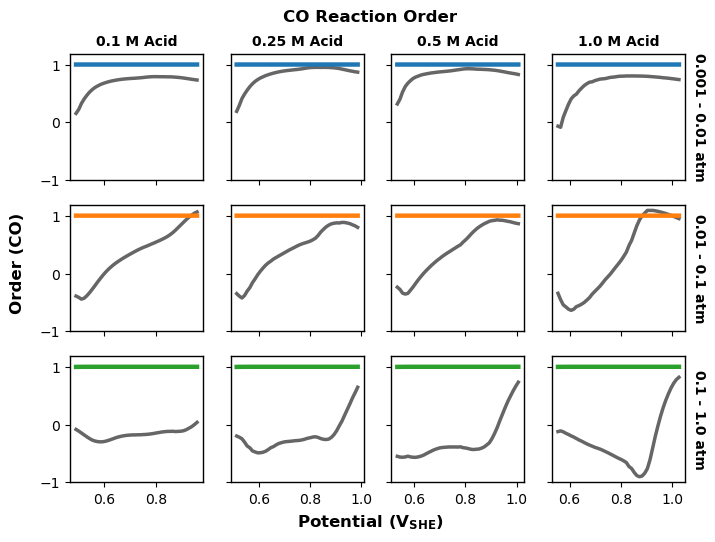

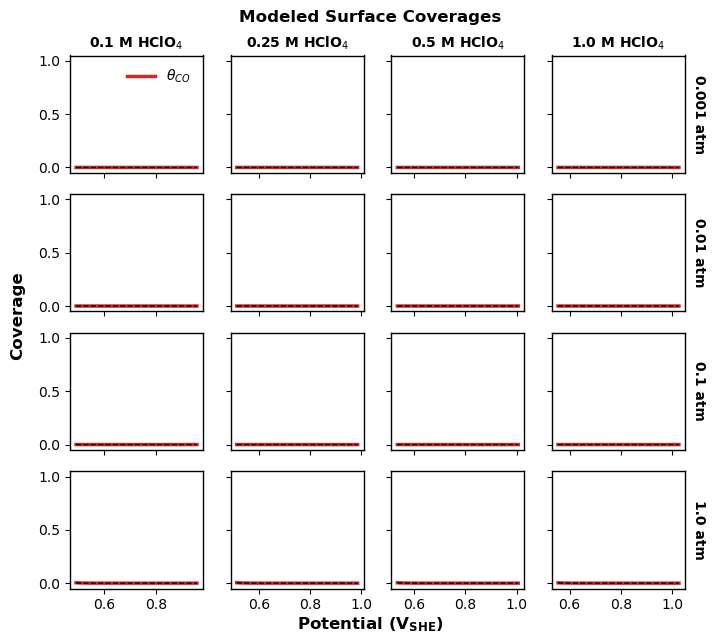

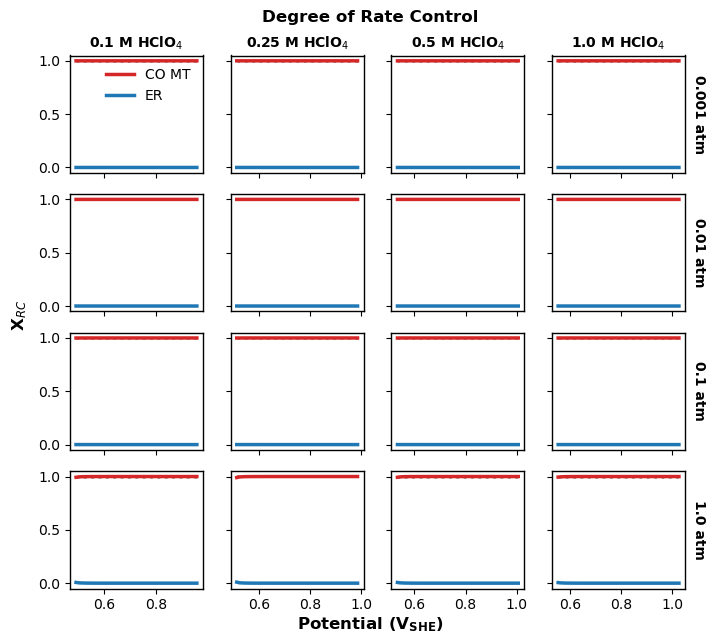

In [17]:
ppc_LH_1_2 = plot_posteriors(trace_LH_1_2, LH_1_2)
plot_model_fits(trace_LH_1_2, ppc_LH_1_2); plot_coverages(trace_LH_1_2)
plot_drc(LH_1_2, trace_LH_1_2, perturb_vars=['delta_BL', 'Gact2_0'], perturb_labels=['CO MT', 'ER'], 
         var_types={'delta_BL': 'resistance', 'Gact2_0': 'Gact'})

# Comparison

      rank    elpd_loo      p_loo   elpd_diff    weight         se        dse  warning scale
BF_2     0  743.452066   8.957903    0.000000  0.758212  66.312018   0.000000    False   log
LH_2     1  141.785291  11.084185  601.666775  0.241788  36.923827  55.724415    False   log


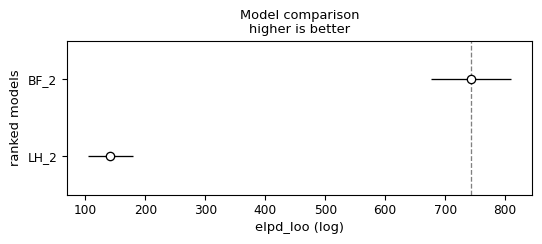

In [14]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "BF_2": loo_BF_2,
    "LH_1_2": loo_LH_1_2,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()